# Spam Email Detection System

In [20]:
# Load Data

import sys
sys.path.append('../SRC')
from data_loader import load_data

path = '../Data/Raw/emails.csv'

df = load_data(path)

In [21]:
# Libraries Import

import pandas as pd

## First 5 row of data

In [22]:
df.head()

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


## Last 5 Rows of Data

In [23]:
df.tail()

,text,spam
5723,Subject: re : research and development charges...,0
5724,"Subject: re : receipts from visit jim , than...",0
5725,Subject: re : enron case study update wow ! a...,0
5726,"Subject: re : interest david , please , call...",0
5727,Subject: news : aurora 5 . 2 update aurora ve...,0


## Dataset dimension

In [24]:
df.shape

(5728, 2)

In [25]:
print(df.groupby('spam').size())

spam
0    4360
1    1368
dtype: int64


<Axes: xlabel='spam'>

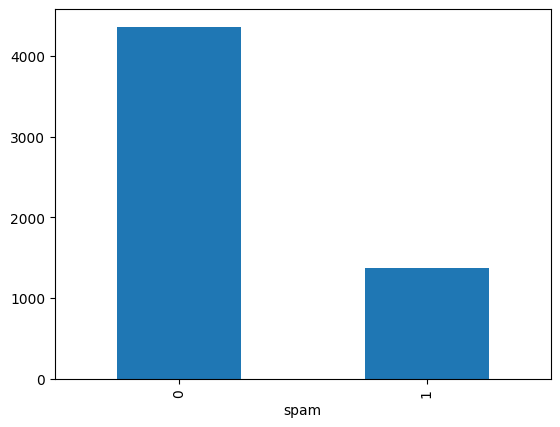

In [26]:
df['spam'].value_counts().plot(kind='bar')

## Resampling

In [27]:
from sklearn.utils import resample

# Separate classes
not_spam = df[df['spam'] == 0]
spam = df[df['spam'] == 1]


undersample = resample(
    not_spam,
    replace=False,
    n_samples=1368,
    random_state=42
)

balance_df = pd.concat ([undersample, spam])

<Axes: xlabel='spam'>

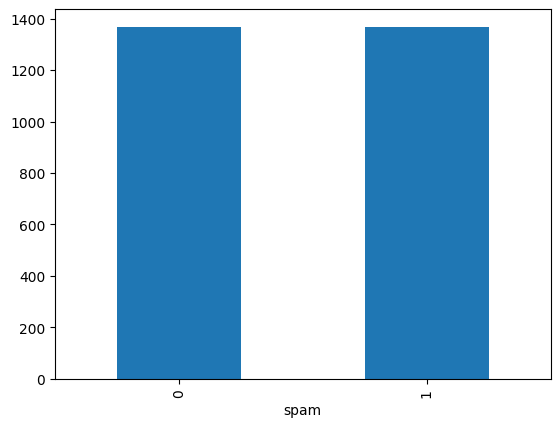

In [28]:
balance_df['spam'].value_counts().plot(kind='bar')

## NLP 

### Preprocessing

In [29]:
from preprocessor import convert_to_clean_text

In [30]:
balance_df['text'] = balance_df['text'].fillna('')
final_df = convert_to_clean_text(balance_df, ['text'])

In [31]:
final_df.head()

,text,spam
1547,subject: interview schedule for jinbaek kim i...,0
2730,"subject: re : wednesday meeting eric , i thi...",0
4843,subject: re : london research group i ' d do ...,0
2856,"subject: re : congratulations vince , thanks ...",0
3804,subject: osman sezgen steve kromer is request...,0


### VECTORIZATION

In [32]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorize = TfidfVectorizer()
x = df['text']
Vector_X = vectorize.fit_transform(x)


In [33]:
# Data Modeling
from sklearn.model_selection import train_test_split
y = df['spam'].values
X_train, X_test, y_train, y_test = train_test_split(
    Vector_X,
    y,
    test_size=0.3,
    random_state=42
)


### Model Implementation

In [34]:
# Importing Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB


In [35]:
m1 = RandomForestClassifier()
m1.fit(X_train,y_train)

m2 = DecisionTreeClassifier()
m2.fit (X_train,y_train)

m3 = MultinomialNB()
m3.fit (X_train,y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [36]:
pred1 = m1.predict(X_test)
pred2 = m2.predict(X_test)
pred3 = m3.predict(X_test)

In [40]:
from sklearn.metrics import classification_report

print('Model 1 Performance')
print(classification_report(y_test,pred1))
print('Model 2 Performance')
print(classification_report(y_test,pred2))
print('Model 3 Performance')
print(classification_report(y_test,pred3))

Model 1 Performance
              precision    recall  f1-score   support

           0       0.94      1.00      0.97      1278
           1       1.00      0.81      0.89       441

    accuracy                           0.95      1719
   macro avg       0.97      0.90      0.93      1719
weighted avg       0.95      0.95      0.95      1719

Model 2 Performance
              precision    recall  f1-score   support

           0       0.96      0.98      0.97      1278
           1       0.93      0.90      0.91       441

    accuracy                           0.96      1719
   macro avg       0.95      0.94      0.94      1719
weighted avg       0.96      0.96      0.96      1719

Model 3 Performance
              precision    recall  f1-score   support

           0       0.82      1.00      0.90      1278
           1       1.00      0.37      0.53       441

    accuracy                           0.84      1719
   macro avg       0.91      0.68      0.72      1719
weighted avg  

In [38]:
import pickle 
pickle.dump(m1,open('../Data/Model/MODEL1.pkl','wb' ))
pickle.dump(m2,open('../Data/Model/MODEL2.pkl','wb' ))
pickle.dump(m3,open('../Data/Model/MODEL3.pkl','wb' ))

pickle.dump(vectorize,open('../Data/Model/Vector.pkl','wb'))